<a href="https://colab.research.google.com/github/gagan3012/ltr/blob/master/notebooks/dst_interactive.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Interactive DST Explorer

Enter a **prompt**, **model name**, **context words**, and **noncontext words** below to run full Distributional Semantics Tracing with both CAS methods (Probability & Cosine).

| CAS Method | Measures | Best for |
|---|---|---|
| **Probability** (softmax) | Which words the model will *predict* at each layer | Misalignment / refusal analysis |
| **Cosine** (abs cosine sim) | How much *information* about each word set is encoded | Hallucination / context retention |

## 1. Setup

In [50]:
!uv pip install git+https://github.com/gagan3012/ltr

Using Python 3.12.12 environment at: /usr
Resolved 127 packages in 683ms                                       
Audited 127 packages in 2ms


In [51]:
import sys, os, warnings
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, Markdown
warnings.filterwarnings("ignore")

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "src")))

from transformers import AutoModelForCausalLM, AutoTokenizer
from ltr.dst import (
    DistributionalSemanticsTracer,
    DSTResult,
    SemanticMap,
    CASTrace,
    SequenceStepResult,
)

try:
    import networkx as nx
except ImportError:
    raise ImportError("networkx is required: pip install networkx")

if torch.cuda.is_available():
    DEVICE = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


## 2. Input Configuration

Edit the variables below and re-run from this cell onward.

In [52]:
# ====================== USER INPUTS ======================

MODEL_NAME = "HuggingFaceTB/SmolLM2-135M-Instruct"  # Any HuggingFace causal LM

PROMPT = "The man went to the river bank to deposit his money can he do it yes or no? Answer:"

CONTEXT_WORDS = ["river", "water", "shore", "stream", "fish", "nature", "No"]

NONCONTEXT_WORDS = ["money", "finance", "account", "loan", "credit", "bank", "Yes"]

TOP_K = 15  # Number of concept nodes per layer

NUM_MAX_TOKENS = 5  # Number of tokens to predict for sequence analysis

# ==========================================================

print(f"Model:            {MODEL_NAME}")
print(f"Prompt:           {PROMPT!r}")
print(f"Context words:    {CONTEXT_WORDS}")
print(f"Noncontext words: {NONCONTEXT_WORDS}")
print(f"Top-K:            {TOP_K}")
print(f"Sequence tokens:  {NUM_MAX_TOKENS}")

Model:            HuggingFaceTB/SmolLM2-135M-Instruct
Prompt:           'The man went to the river bank to deposit his money can he do it yes or no? Answer:'
Context words:    ['river', 'water', 'shore', 'stream', 'fish', 'nature', 'No']
Noncontext words: ['money', 'finance', 'account', 'loan', 'credit', 'bank', 'Yes']
Top-K:            15
Sequence tokens:  5


## 3. Load Model & Tokenizer

In [53]:
print(f"Loading model: {MODEL_NAME} ...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, torch_dtype=torch.float32,
).to(DEVICE)
model.eval()

# Detect layer prefix
cfg = model.config
n_layers = getattr(cfg, "num_hidden_layers", getattr(cfg, "n_layer", 12))
d_model = getattr(cfg, "hidden_size", getattr(cfg, "n_embd", None))

# Auto-detect layer prefix
LAYER_PREFIX = "model.layers."
for prefix_candidate in ["model.layers.", "transformer.h.", "gpt_neox.layers."]:
    try:
        _ = dict(model.named_modules())
        first_layer = prefix_candidate + "0"
        if first_layer in dict(model.named_modules()):
            LAYER_PREFIX = prefix_candidate
            break
    except Exception:
        pass

print(f"Layers: {n_layers}  |  Width: {d_model}  |  Prefix: {LAYER_PREFIX}")
print("Model loaded.")

Loading model: HuggingFaceTB/SmolLM2-135M-Instruct ...


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Layers: 30  |  Width: 576  |  Prefix: model.layers.
Model loaded.


## 4. Build DST Tracer & Run Both CAS Methods

Running DST with Probability CAS ...


Building semantic maps: 100%|██████████| 6/6 [00:02<00:00,  2.52it/s]


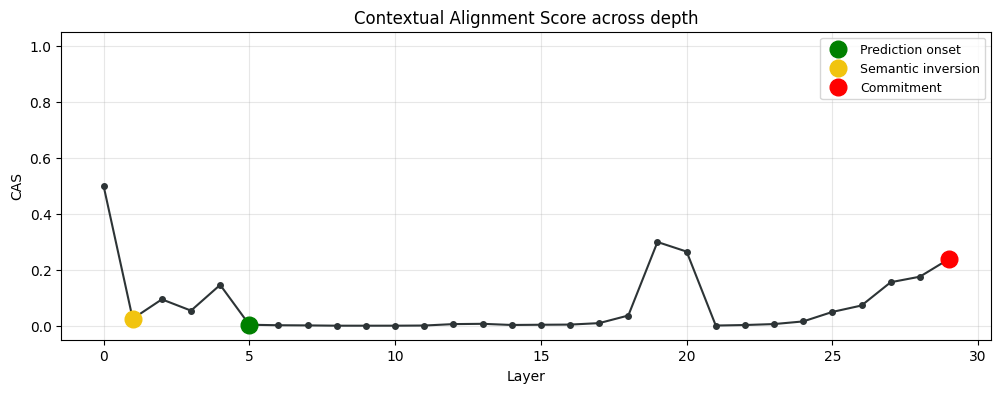

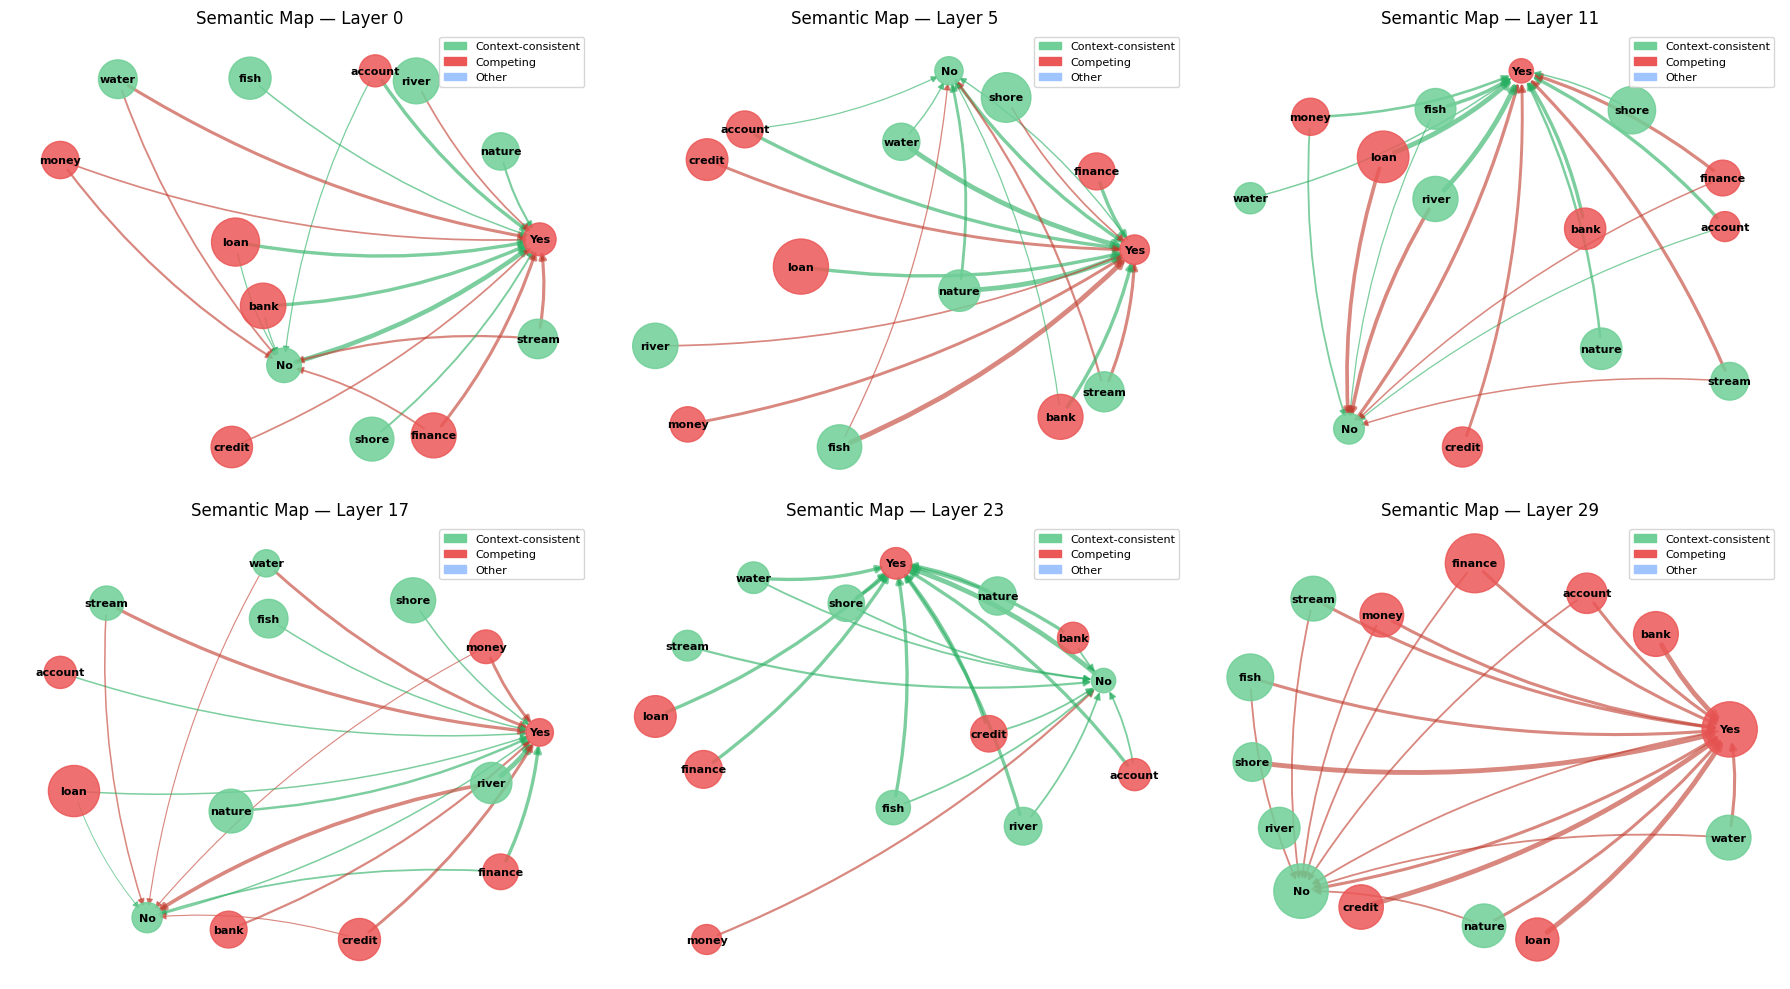

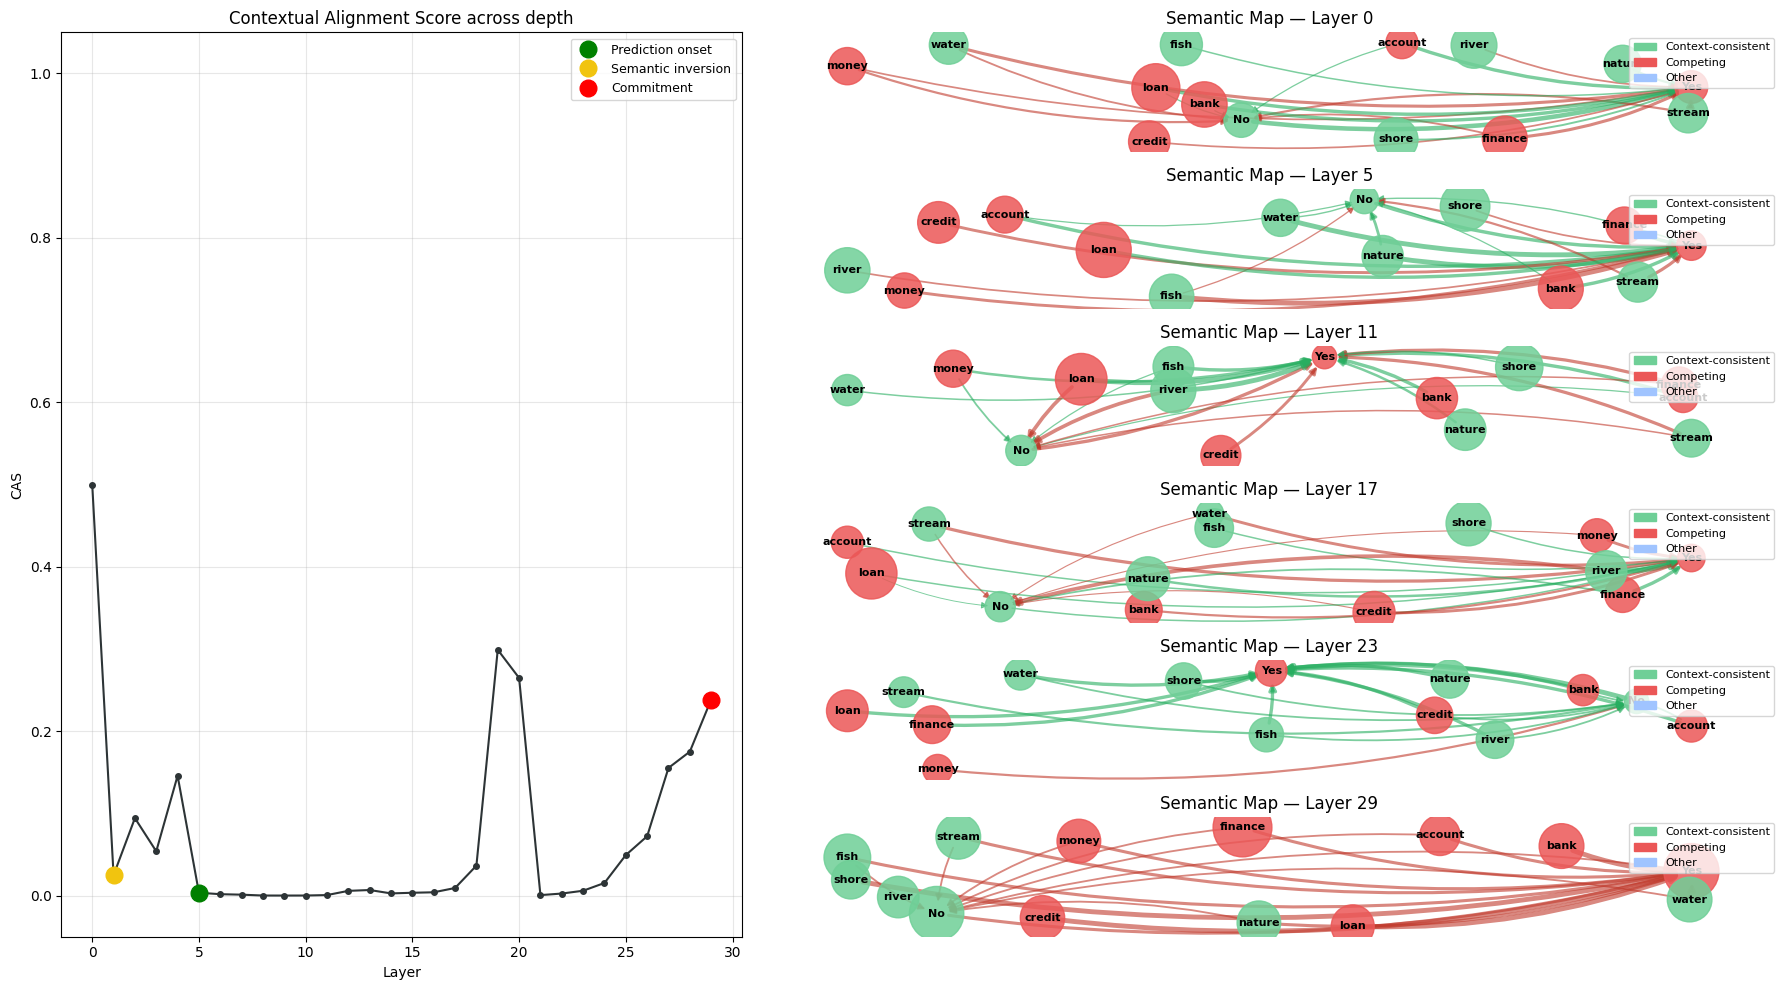

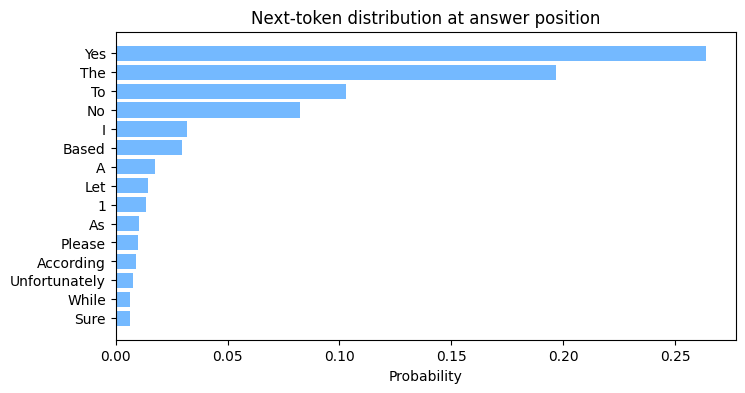

Running DST with Cosine CAS ...


Building semantic maps: 100%|██████████| 6/6 [00:02<00:00,  2.30it/s]


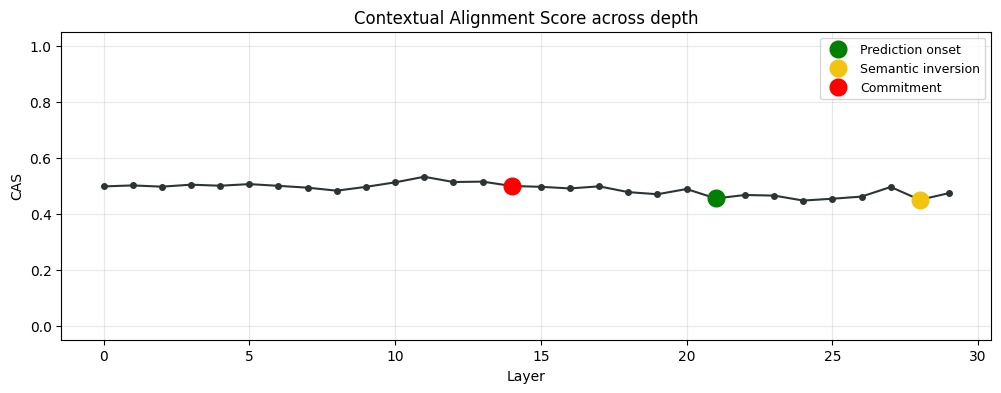

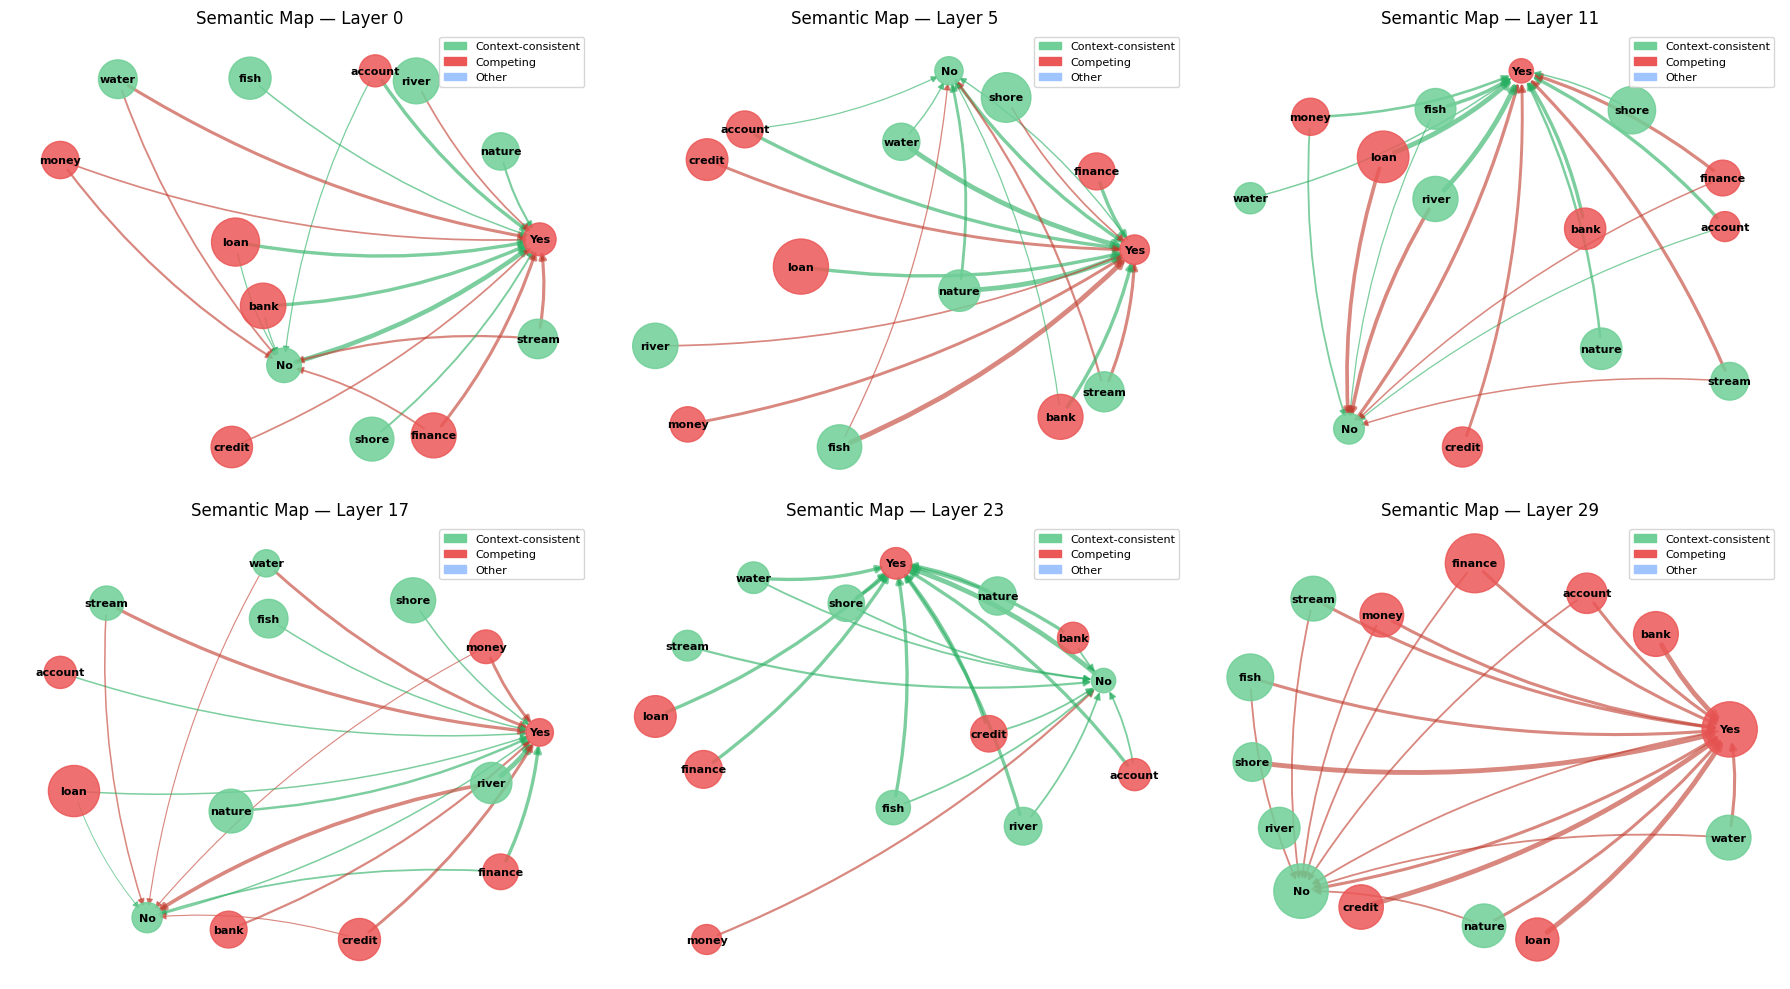

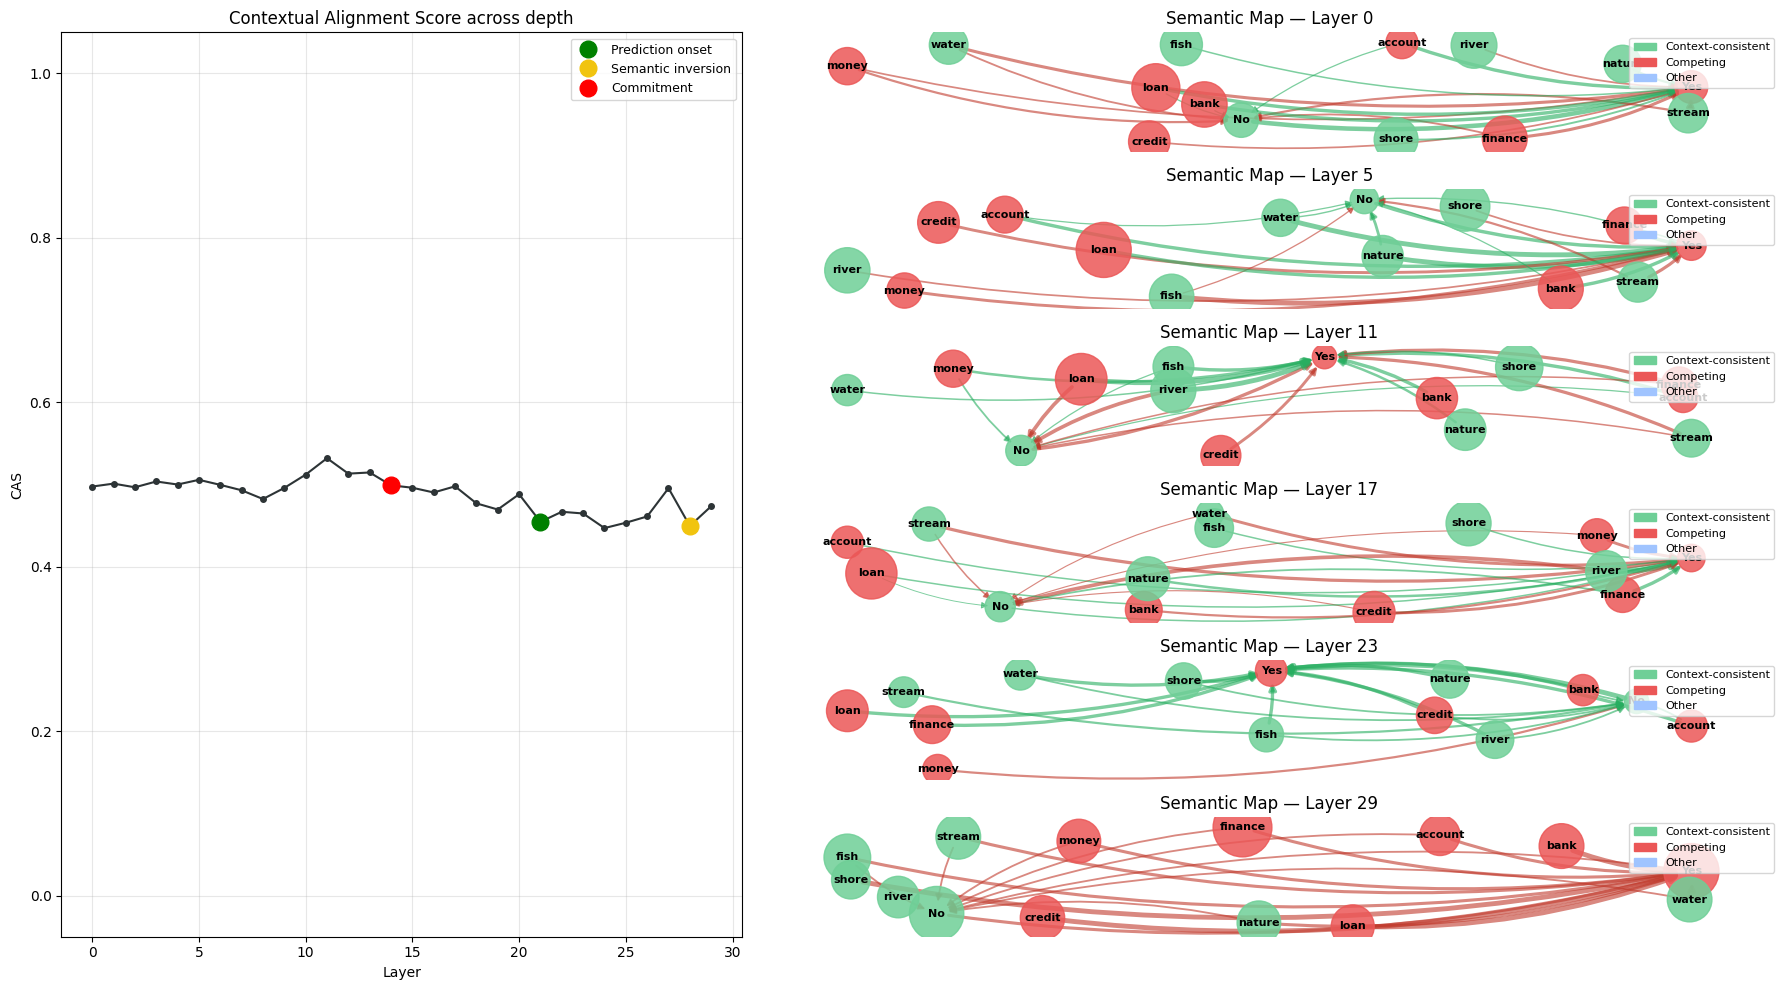

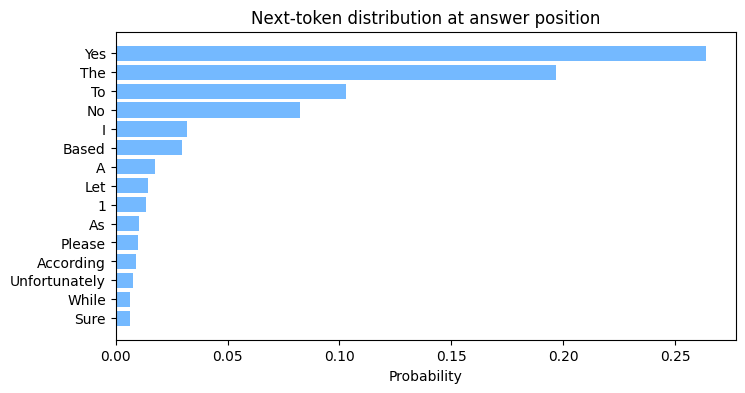


Generated text: 'Yes.'
Done.


In [54]:
tracer = DistributionalSemanticsTracer(
    model, tokenizer, device=DEVICE, layer_prefix=LAYER_PREFIX
)

print("Running DST with Probability CAS ...")
result_prob = tracer.run_analysis(
    prompt=PROMPT,
    context_words=CONTEXT_WORDS,
    noncontext_words=NONCONTEXT_WORDS,
    K=TOP_K,
    compute_edges=True,
    cas_method="probability",
)

# CAS trace
fig_cas = tracer.plot_cas_trace(result_prob.cas_trace, figsize=(12, 4))
plt.show()

# Semantic maps grid
fig_maps = tracer.plot_layer_maps_grid(
    result_prob,
    context_words=CONTEXT_WORDS,
    noncontext_words=NONCONTEXT_WORDS,
    cols=3,
)
plt.show()

# Combined summary (CAS + selected maps)
fig_summary = tracer.plot_dst_summary(
    result_prob,
    context_words=CONTEXT_WORDS,
    noncontext_words=NONCONTEXT_WORDS,
)
plt.show()

# Next-token probs
fig_probs = tracer.plot_next_token_probs(result_prob.next_token_probs, top_n=15)
plt.show()

print("Running DST with Cosine CAS ...")
result_cos = tracer.run_analysis(
    prompt=PROMPT,
    context_words=CONTEXT_WORDS,
    noncontext_words=NONCONTEXT_WORDS,
    K=TOP_K,
    compute_edges=True,
    cas_method="cosine",
)

# CAS trace
fig_cas = tracer.plot_cas_trace(result_cos.cas_trace, figsize=(12, 4))
plt.show()

# Semantic maps grid
fig_maps = tracer.plot_layer_maps_grid(
    result_cos,
    context_words=CONTEXT_WORDS,
    noncontext_words=NONCONTEXT_WORDS,
    cols=3,
)
plt.show()

# Combined summary (CAS + selected maps)
fig_summary = tracer.plot_dst_summary(
    result_cos,
    context_words=CONTEXT_WORDS,
    noncontext_words=NONCONTEXT_WORDS,
)
plt.show()

# Next-token probs
fig_probs = tracer.plot_next_token_probs(result_cos.next_token_probs, top_n=15)
plt.show()


print(f"\nGenerated text: {result_prob.generated_text!r}")
print("Done.")

## 5. CAS Traces — Probability vs Cosine (Side by Side)

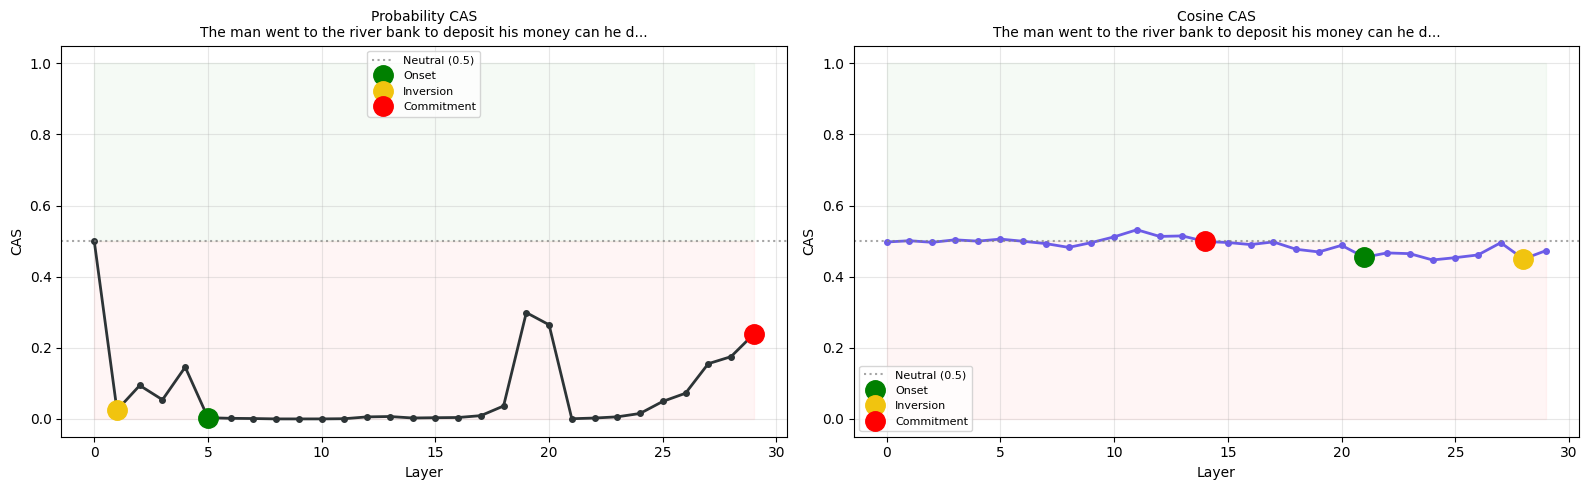

In [55]:
fig, (ax_p, ax_c) = plt.subplots(1, 2, figsize=(16, 5))

for ax, cas_trace, method_name, color in [
    (ax_p, result_prob.cas_trace, "Probability CAS", "#2d3436"),
    (ax_c, result_cos.cas_trace, "Cosine CAS", "#6c5ce7"),
]:
    layers = list(range(len(cas_trace.cas_values)))
    ax.plot(layers, cas_trace.cas_values, "o-", color=color, linewidth=2, markersize=4)
    ax.axhline(0.5, color="grey", linestyle=":", alpha=0.7, label="Neutral (0.5)")
    ax.fill_between(layers, 0.5, 1.0, alpha=0.04, color="green")
    ax.fill_between(layers, 0.0, 0.5, alpha=0.04, color="red")

    if cas_trace.onset_layer is not None:
        ax.plot(cas_trace.onset_layer, cas_trace.cas_values[cas_trace.onset_layer],
                "o", color="green", markersize=14, zorder=5, label="Onset")
    if cas_trace.inversion_layer is not None:
        ax.plot(cas_trace.inversion_layer, cas_trace.cas_values[cas_trace.inversion_layer],
                "o", color="#f1c40f", markersize=14, zorder=5, label="Inversion")
    if cas_trace.commitment_layer is not None:
        ax.plot(cas_trace.commitment_layer, cas_trace.cas_values[cas_trace.commitment_layer],
                "o", color="red", markersize=14, zorder=5, label="Commitment")

    ax.set_xlabel("Layer")
    ax.set_ylabel("CAS")
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f"{method_name}\n{PROMPT[:60]}...", fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. CAS Traces Overlaid

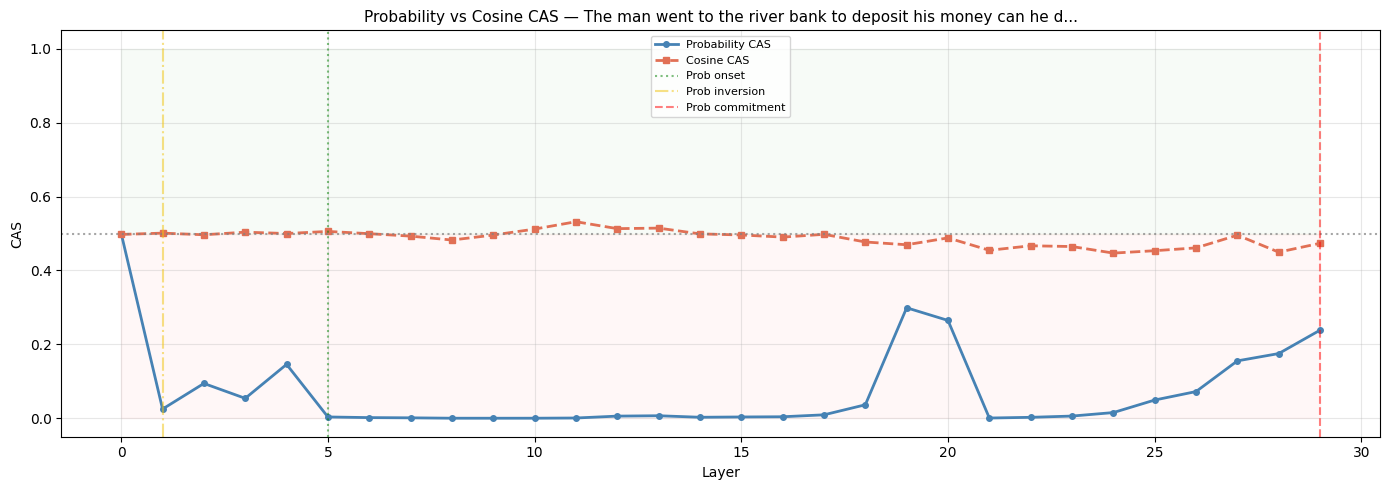

In [56]:
fig, ax = plt.subplots(figsize=(14, 5))

layers = list(range(len(result_prob.cas_trace.cas_values)))
ax.plot(layers, result_prob.cas_trace.cas_values, "o-", color="steelblue",
        linewidth=2, markersize=4, label="Probability CAS")
ax.plot(layers, result_cos.cas_trace.cas_values, "s--", color="#e17055",
        linewidth=2, markersize=4, label="Cosine CAS")
ax.axhline(0.5, color="grey", linestyle=":", alpha=0.7)
ax.fill_between(layers, 0.5, 1.0, alpha=0.03, color="green")
ax.fill_between(layers, 0.0, 0.5, alpha=0.03, color="red")

# Markers for probability CAS
ct = result_prob.cas_trace
if ct.onset_layer is not None:
    ax.axvline(ct.onset_layer, color="green", linestyle=":", alpha=0.5, label="Prob onset")
if ct.inversion_layer is not None:
    ax.axvline(ct.inversion_layer, color="#f1c40f", linestyle="-.", alpha=0.5, label="Prob inversion")
if ct.commitment_layer is not None:
    ax.axvline(ct.commitment_layer, color="red", linestyle="--", alpha=0.5, label="Prob commitment")

ax.set_xlabel("Layer")
ax.set_ylabel("CAS")
ax.set_ylim(-0.05, 1.05)
ax.set_title(f"Probability vs Cosine CAS — {PROMPT[:60]}...", fontsize=11)
ax.legend(fontsize=8, loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Layer Markers Summary

In [57]:
import pandas as pd

rows = []
for method, res in [("Probability", result_prob), ("Cosine", result_cos)]:
    ct = res.cas_trace
    cas = np.array(ct.cas_values)
    rows.append({
        "CAS Method": method,
        "Onset Layer": ct.onset_layer,
        "Inversion Layer": ct.inversion_layer,
        "Commitment Layer": ct.commitment_layer,
        "Mean CAS": f"{cas.mean():.4f}",
        "Final CAS": f"{cas[-1]:.4f}",
        "Min CAS": f"{cas.min():.4f}",
        "Max CAS": f"{cas.max():.4f}",
    })

df_markers = pd.DataFrame(rows)
display(df_markers)

,CAS Method,Onset Layer,Inversion Layer,Commitment Layer,Mean CAS,Final CAS,Min CAS,Max CAS
0,Probability,5,1,29,0.0724,0.2384,0.0001,0.5000
1,Cosine,21,28,14,0.4877,0.4736,0.4470,0.5320


## 8. Next-Token Probability Distribution

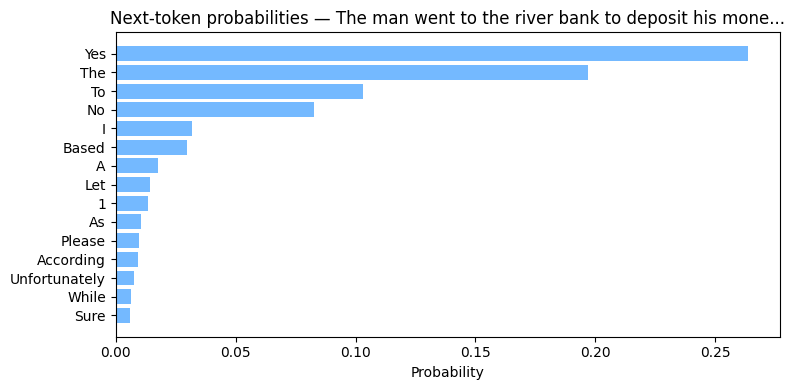

In [58]:
fig = tracer.plot_next_token_probs(result_prob.next_token_probs, top_n=20)
plt.title(f"Next-token probabilities — {PROMPT[:50]}...")
plt.tight_layout()
plt.show()

## 9. Semantic Maps at Key Layers (Probability CAS)

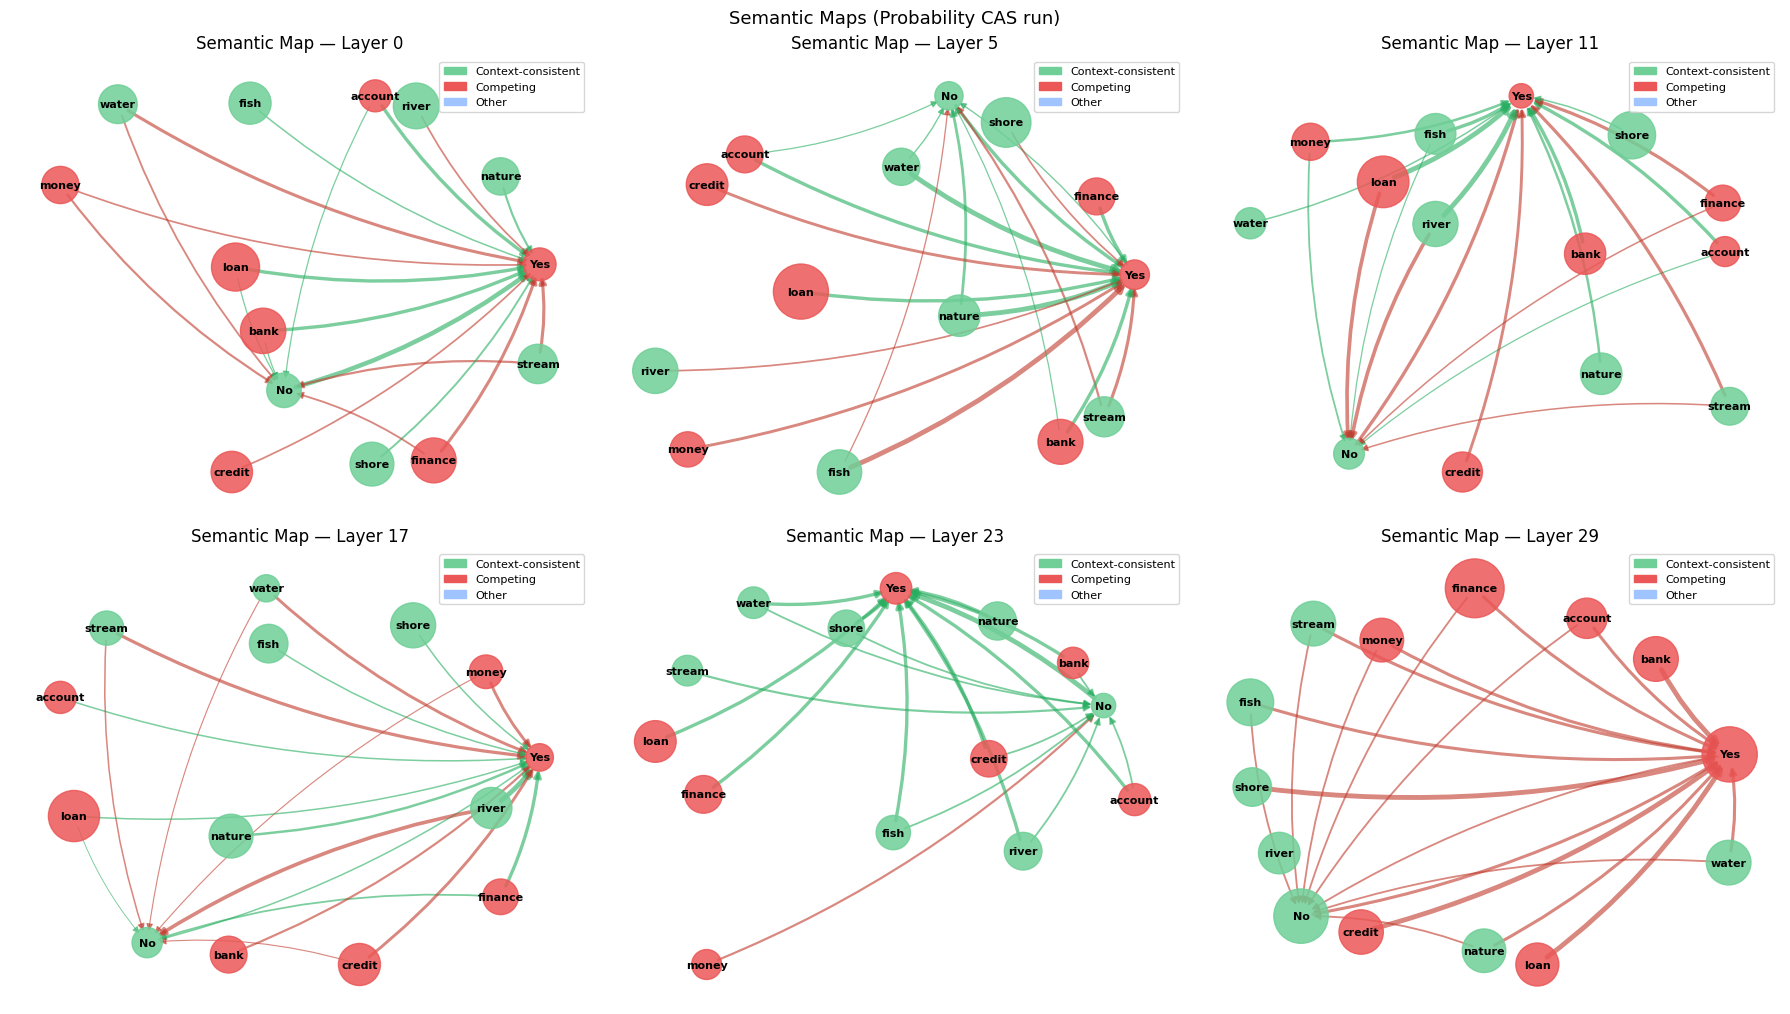

In [59]:
fig = tracer.plot_layer_maps_grid(
    result_prob,
    context_words=CONTEXT_WORDS,
    noncontext_words=NONCONTEXT_WORDS,
    cols=3,
)
fig.suptitle("Semantic Maps (Probability CAS run)", fontsize=13, y=1.01)
plt.show()

## 10. DST Summary Figure (Probability CAS)

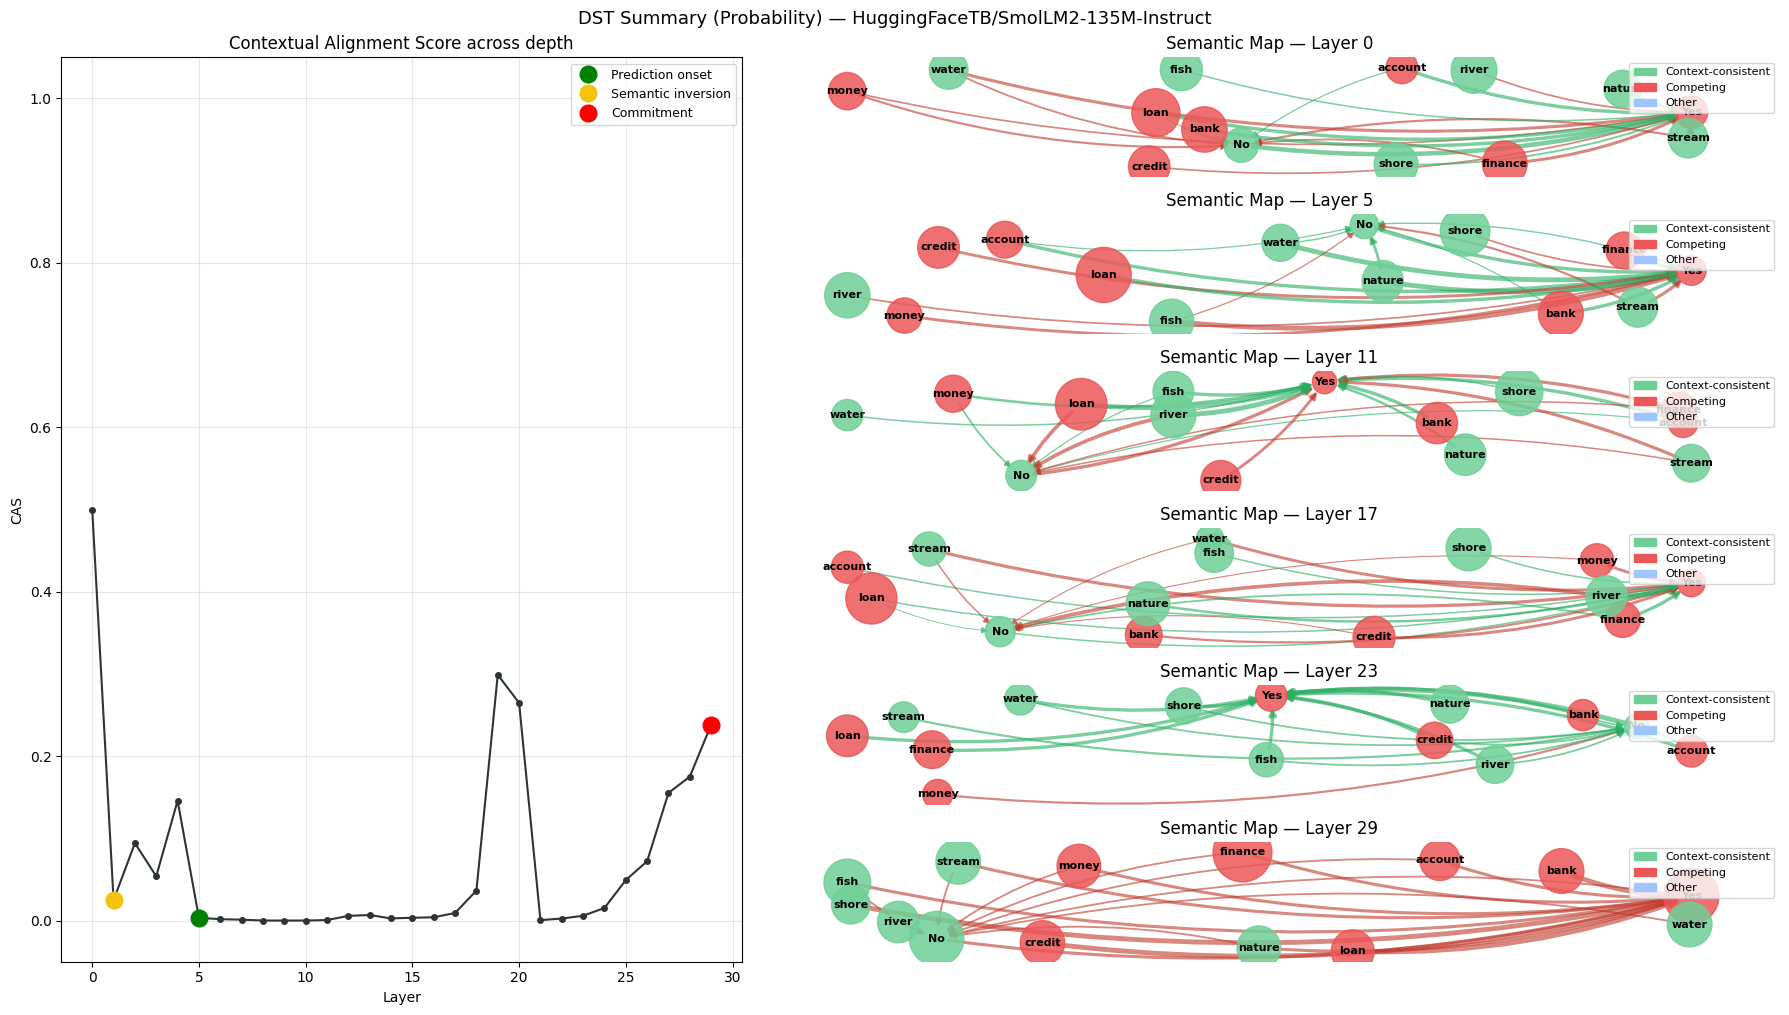

In [60]:
fig = tracer.plot_dst_summary(
    result_prob,
    context_words=CONTEXT_WORDS,
    noncontext_words=NONCONTEXT_WORDS,
)
fig.suptitle(f"DST Summary (Probability) — {MODEL_NAME}", fontsize=13, y=1.01)
plt.show()

## 11. DST Summary Figure (Cosine CAS)

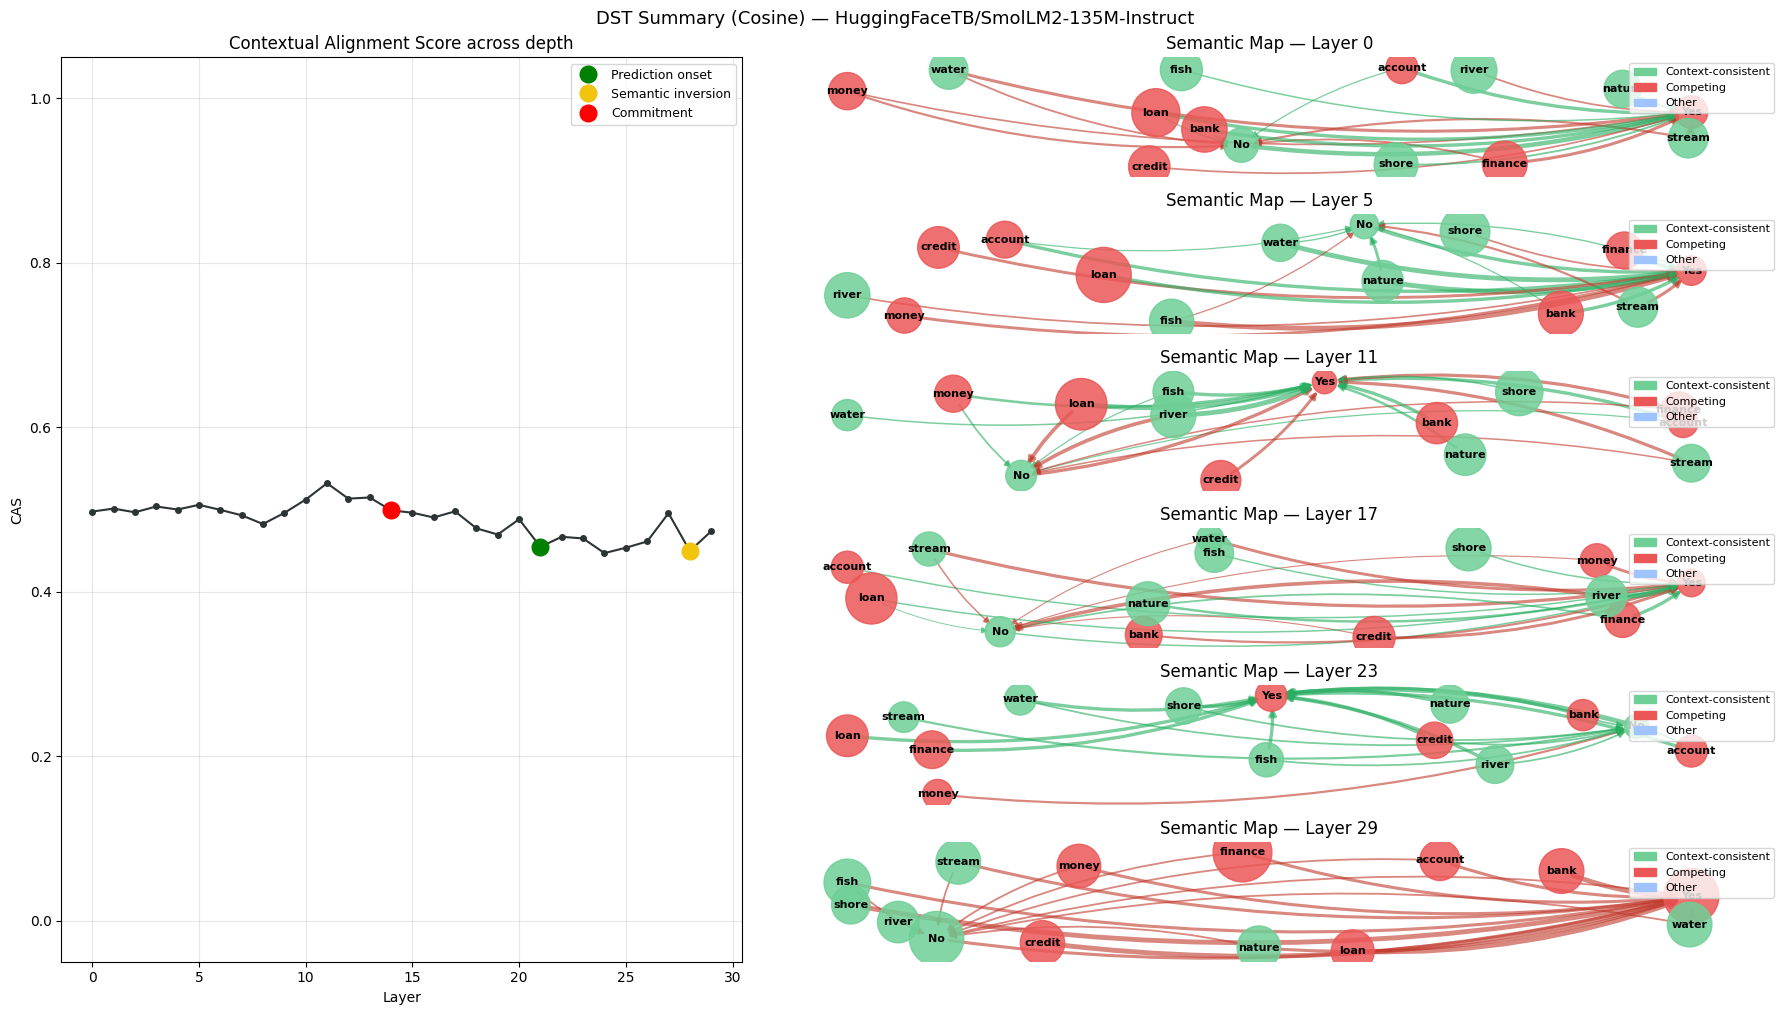

In [61]:
fig = tracer.plot_dst_summary(
    result_cos,
    context_words=CONTEXT_WORDS,
    noncontext_words=NONCONTEXT_WORDS,
)
fig.suptitle(f"DST Summary (Cosine) — {MODEL_NAME}", fontsize=13, y=1.01)
plt.show()

## 12. Concept Scores Distribution (Early / Mid / Late)

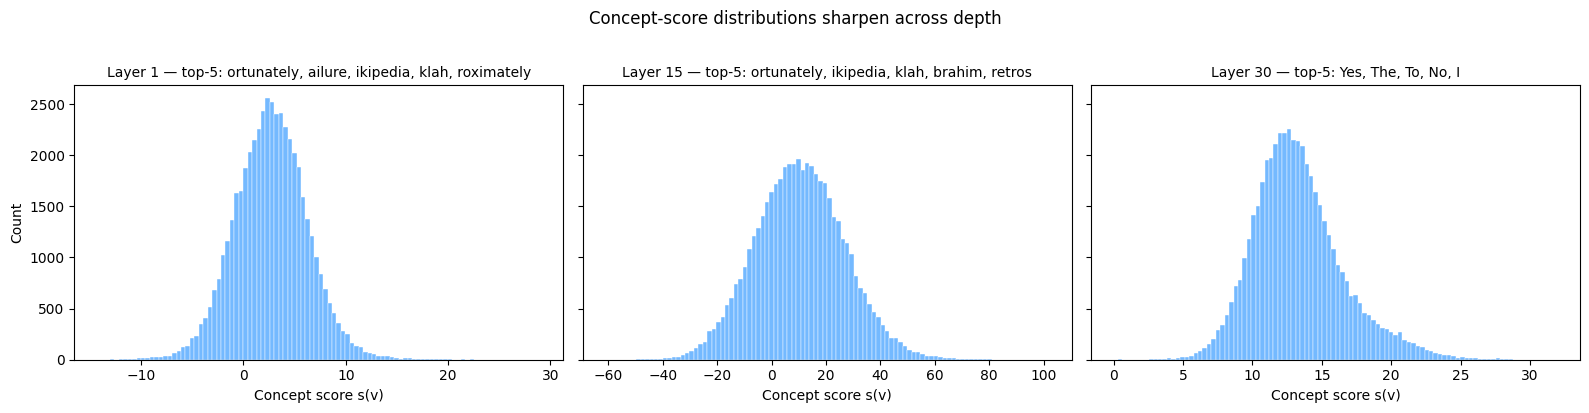

In [62]:
# Extract residual stream for the prompt
@torch.no_grad()
def extract_residual_stream(model, tokenizer, prompt, device=DEVICE):
    # Apply chat template if available
    if hasattr(tokenizer, "apply_chat_template"):
        try:
            formatted = tokenizer.apply_chat_template(
                [{"role": "user", "content": prompt}],
                tokenize=False, add_generation_prompt=True,
            )
        except Exception:
            formatted = prompt
    else:
        formatted = prompt
    inputs = tokenizer(formatted, return_tensors="pt").to(device)
    outputs = model(**inputs, output_hidden_states=True)
    answer_pos = inputs["input_ids"].shape[1] - 1
    hs = torch.stack([h[0, answer_pos] for h in outputs.hidden_states])
    return hs

# Get unembedding matrix
if hasattr(model, "lm_head"):
    U = model.lm_head.weight.detach().to(DEVICE)
elif hasattr(model, "get_output_embeddings"):
    U = model.get_output_embeddings().weight.detach().to(DEVICE)
else:
    U = model.get_input_embeddings().weight.detach().to(DEVICE)

hs = extract_residual_stream(model, tokenizer, PROMPT)
concept_scores = hs @ U.T  # (L+1, |V|)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
layer_picks = [1, n_layers // 2, n_layers]

for ax, l in zip(axes, layer_picks):
    scores_np = concept_scores[l].cpu().numpy()
    ax.hist(scores_np, bins=100, color="#74b9ff", edgecolor="white", linewidth=0.3)
    top5 = concept_scores[l].topk(5)
    top5_words = [tokenizer.decode([tid]).strip() for tid in top5.indices.tolist()]
    ax.set_title(f"Layer {l} — top-5: {', '.join(top5_words)}", fontsize=10)
    ax.set_xlabel("Concept score s(v)")

axes[0].set_ylabel("Count")
fig.suptitle("Concept-score distributions sharpen across depth", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 13. Top Causal Edges by Layer

In [63]:
print(f"{'Layer':>5}  {'Source':>18} → {'Target':<18}  {'Weight':>10}  {'Pos':>4}")
print("-" * 65)

for layer in sorted(result_prob.semantic_maps.keys()):
    sm = result_prob.semantic_maps[layer]
    for e in sm.edges[:3]:  # top 3 per layer
        print(f"{layer:5d}  {e.source:>18} → {e.target:<18}  {e.weight:+10.5f}  {e.source_position:4d}")

Layer              Source → Target                  Weight   Pos
-----------------------------------------------------------------
    0                  No → Yes                   +0.09206    32
    0             account → Yes                   +0.06481     7
    0                bank → Yes                   +0.06481     7
    5                fish → Yes                   -0.24761    36
    5              nature → Yes                   +0.20836    41
    5               water → Yes                   +0.12488    27
   11               river → Yes                   +0.20384    40
   11                loan → Yes                   +0.20384    40
   11               river → No                    -0.07143    40
   17               river → Yes                   +0.20384    40
   17               river → No                    -0.07143    40
   17             finance → Yes                   +0.06356    47
   23                  No → Yes                   +0.11449    44
   23                ban

## 14. Per-Layer CAS Values Table

In [64]:
cas_p = result_prob.cas_trace.cas_values
cas_c = result_cos.cas_trace.cas_values

cas_rows = []
for i in range(len(cas_p)):
    markers = []
    for method, ct in [("P", result_prob.cas_trace), ("C", result_cos.cas_trace)]:
        if i == ct.onset_layer:
            markers.append(f"{method}-Onset")
        if i == ct.inversion_layer:
            markers.append(f"{method}-Inversion")
        if i == ct.commitment_layer:
            markers.append(f"{method}-Commitment")
    cas_rows.append({
        "Layer": i,
        "Prob CAS": f"{cas_p[i]:.4f}",
        "Cosine CAS": f"{cas_c[i]:.4f}",
        "Markers": ", ".join(markers) if markers else "",
    })

df_cas = pd.DataFrame(cas_rows)
display(df_cas)

,Layer,Prob CAS,Cosine CAS,Markers
0,0,0.5000,0.4975,
1,1,0.0249,0.5011,P-Inversion
2,2,0.0942,0.4966,
3,3,0.0539,0.5037,
4,4,0.1458,0.5000,
5,5,0.0035,0.5057,P-Onset
6,6,0.0017,0.4996,
7,7,0.0011,0.4930,
8,8,0.0001,0.4824,
9,9,0.0001,0.4959,


## 15. Misalignment Drift Score (MDS)

In [65]:
for method, res in [("Probability", result_prob), ("Cosine", result_cos)]:
    cas = np.array(res.cas_trace.cas_values)
    drift_mask = cas < 0.5
    mds = float((0.5 - cas[drift_mask]).mean()) if drift_mask.any() else 0.0
    n_drift = int(drift_mask.sum())
    print(f"{method} CAS:")
    print(f"  MDS (mean drift below 0.5): {mds:.4f}")
    print(f"  Layers below neutral:       {n_drift}/{len(cas)}")
    print(f"  Final CAS:                  {cas[-1]:.4f}")
    print()

Probability CAS:
  MDS (mean drift below 0.5): 0.4423
  Layers below neutral:       29/30
  Final CAS:                  0.2384

Cosine CAS:
  MDS (mean drift below 0.5): 0.0205
  Layers below neutral:       22/30
  Final CAS:                  0.4736



## 16. Concept Node Details at Selected Layers

In [66]:
ctx_set = set(CONTEXT_WORDS)
nonctx_set = set(NONCONTEXT_WORDS)

for layer in sorted(result_prob.semantic_maps.keys()):
    sm = result_prob.semantic_maps[layer]
    print(f"\n--- Layer {layer}: {len(sm.nodes)} nodes, {len(sm.edges)} edges ---")
    for n in sm.nodes[:10]:
        tag = ""
        if n.word.lower() in ctx_set or n.word in ctx_set:
            tag = " [CTX]"
        elif n.word.lower() in nonctx_set or n.word in nonctx_set:
            tag = " [NONCTX]"
        print(f"  {n.word:20s}  score={n.score:+8.3f}  affinity={n.affinity:+.4f}{tag}")


--- Layer 0: 14 nodes, 37 edges ---
  account               score=  -5.752  affinity=-0.0442 [NONCTX]
  Yes                   score=  -6.431  affinity=-0.0554 [NONCTX]
  No                    score=  -7.944  affinity=-0.0724 [CTX]
  money                 score= -10.451  affinity=-0.0820 [NONCTX]
  nature                score= -10.533  affinity=-0.0704 [CTX]
  water                 score= -11.892  affinity=-0.0863 [CTX]
  stream                score= -12.624  affinity=-0.0830 [CTX]
  credit                score= -14.716  affinity=-0.1072 [NONCTX]
  fish                  score= -15.455  affinity=-0.1128 [CTX]
  shore                 score= -17.399  affinity=-0.1008 [CTX]

--- Layer 5: 14 nodes, 39 edges ---
  No                    score=  -2.854  affinity=-0.0312 [CTX]
  Yes                   score=  -3.793  affinity=-0.0391 [NONCTX]
  money                 score=  -8.589  affinity=-0.0807 [NONCTX]
  account               score= -10.102  affinity=-0.0931 [NONCTX]
  finance              

---

## 17. Sequence Prediction Analysis

Instead of analysing only the **single next token**, sequence prediction runs DST at every step of an autoregressive generation (up to `NUM_MAX_TOKENS`).  This captures how semantic alignment evolves as the model commits to successive tokens — essential for multi-token answers like entity names or phrases.

The aggregated **Sequence CAS** uses probability-weighted averaging: tokens the model is more confident about contribute more.

In [67]:
print(f"Running sequence DST (num_max_tokens={NUM_MAX_TOKENS}) with Probability CAS ...")
result_seq = tracer.run_analysis(
    prompt=PROMPT,
    context_words=CONTEXT_WORDS,
    noncontext_words=NONCONTEXT_WORDS,
    K=TOP_K,
    compute_edges=True,
    cas_method="probability",
    num_max_tokens=NUM_MAX_TOKENS,
)

print(f"\nPredicted sequence: {result_seq.generated_text!r}")
print(f"Steps completed:   {len(result_seq.sequence_steps)}")
print()
for step in result_seq.sequence_steps:
    print(f"  Step {step.step}: '{step.token_word}' (p={step.token_prob:.4f})")

Running sequence DST (num_max_tokens=5) with Probability CAS ...


Sequence DST (5 tokens):  40%|████      | 2/5 [00:07<00:11,  3.70s/it]


Predicted sequence: 'Yes.'
Steps completed:   3

  Step 0: 'Yes' (p=0.2637)
  Step 1: '.' (p=0.4552)
  Step 2: '' (p=0.7588)


## 18. Sequence CAS — Per-Token Overlay & Aggregated Trace

Each thin line is one token's CAS trace; the thick line is the probability-weighted aggregate.

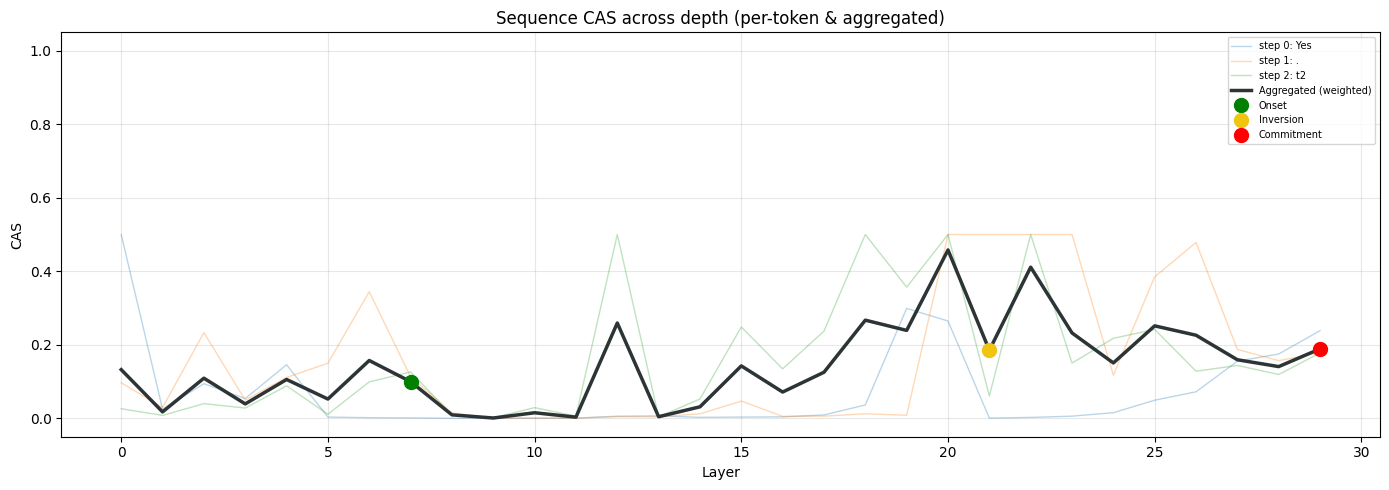

In [68]:
fig = tracer.plot_sequence_cas_overlay(result_seq, figsize=(14, 5))
plt.tight_layout()
plt.show()

## 19. Sequence CAS Heatmap (Layers × Tokens)

Red = low CAS (competing interpretation dominates), Green = high CAS (context-consistent).

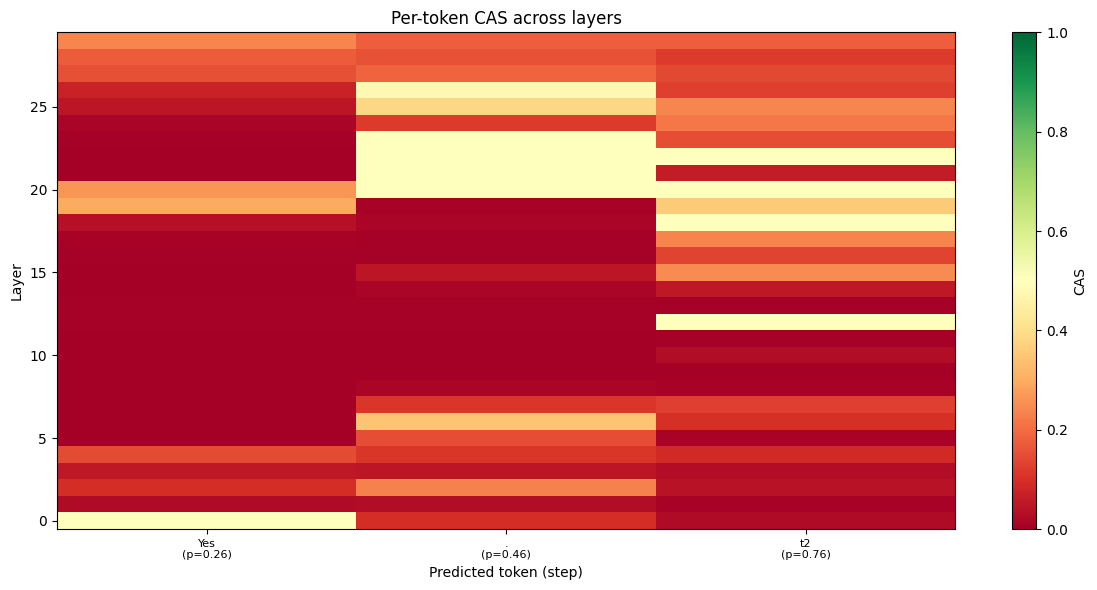

In [69]:
fig = tracer.plot_sequence_cas_heatmap(result_seq, figsize=(12, 6))
plt.tight_layout()
plt.show()

## 20. Per-Token Confidence

Bar chart showing the model's greedy probability at each step. Green = confident (>0.5), orange = moderate, red = uncertain (<0.2).

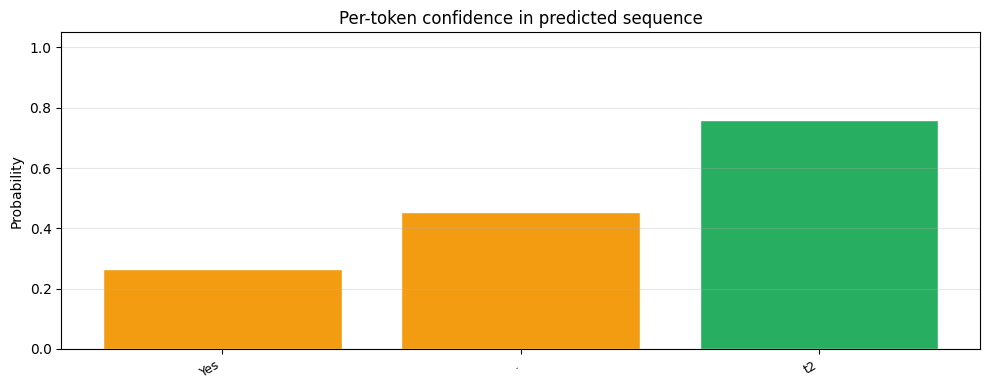

In [70]:
fig = tracer.plot_sequence_token_confidence(result_seq, figsize=(10, 4))
plt.tight_layout()
plt.show()

## 21. Sequence DST Combined Summary

Three-panel overview: aggregated CAS trace (top-left), per-token confidence (top-right), and CAS heatmap (bottom).

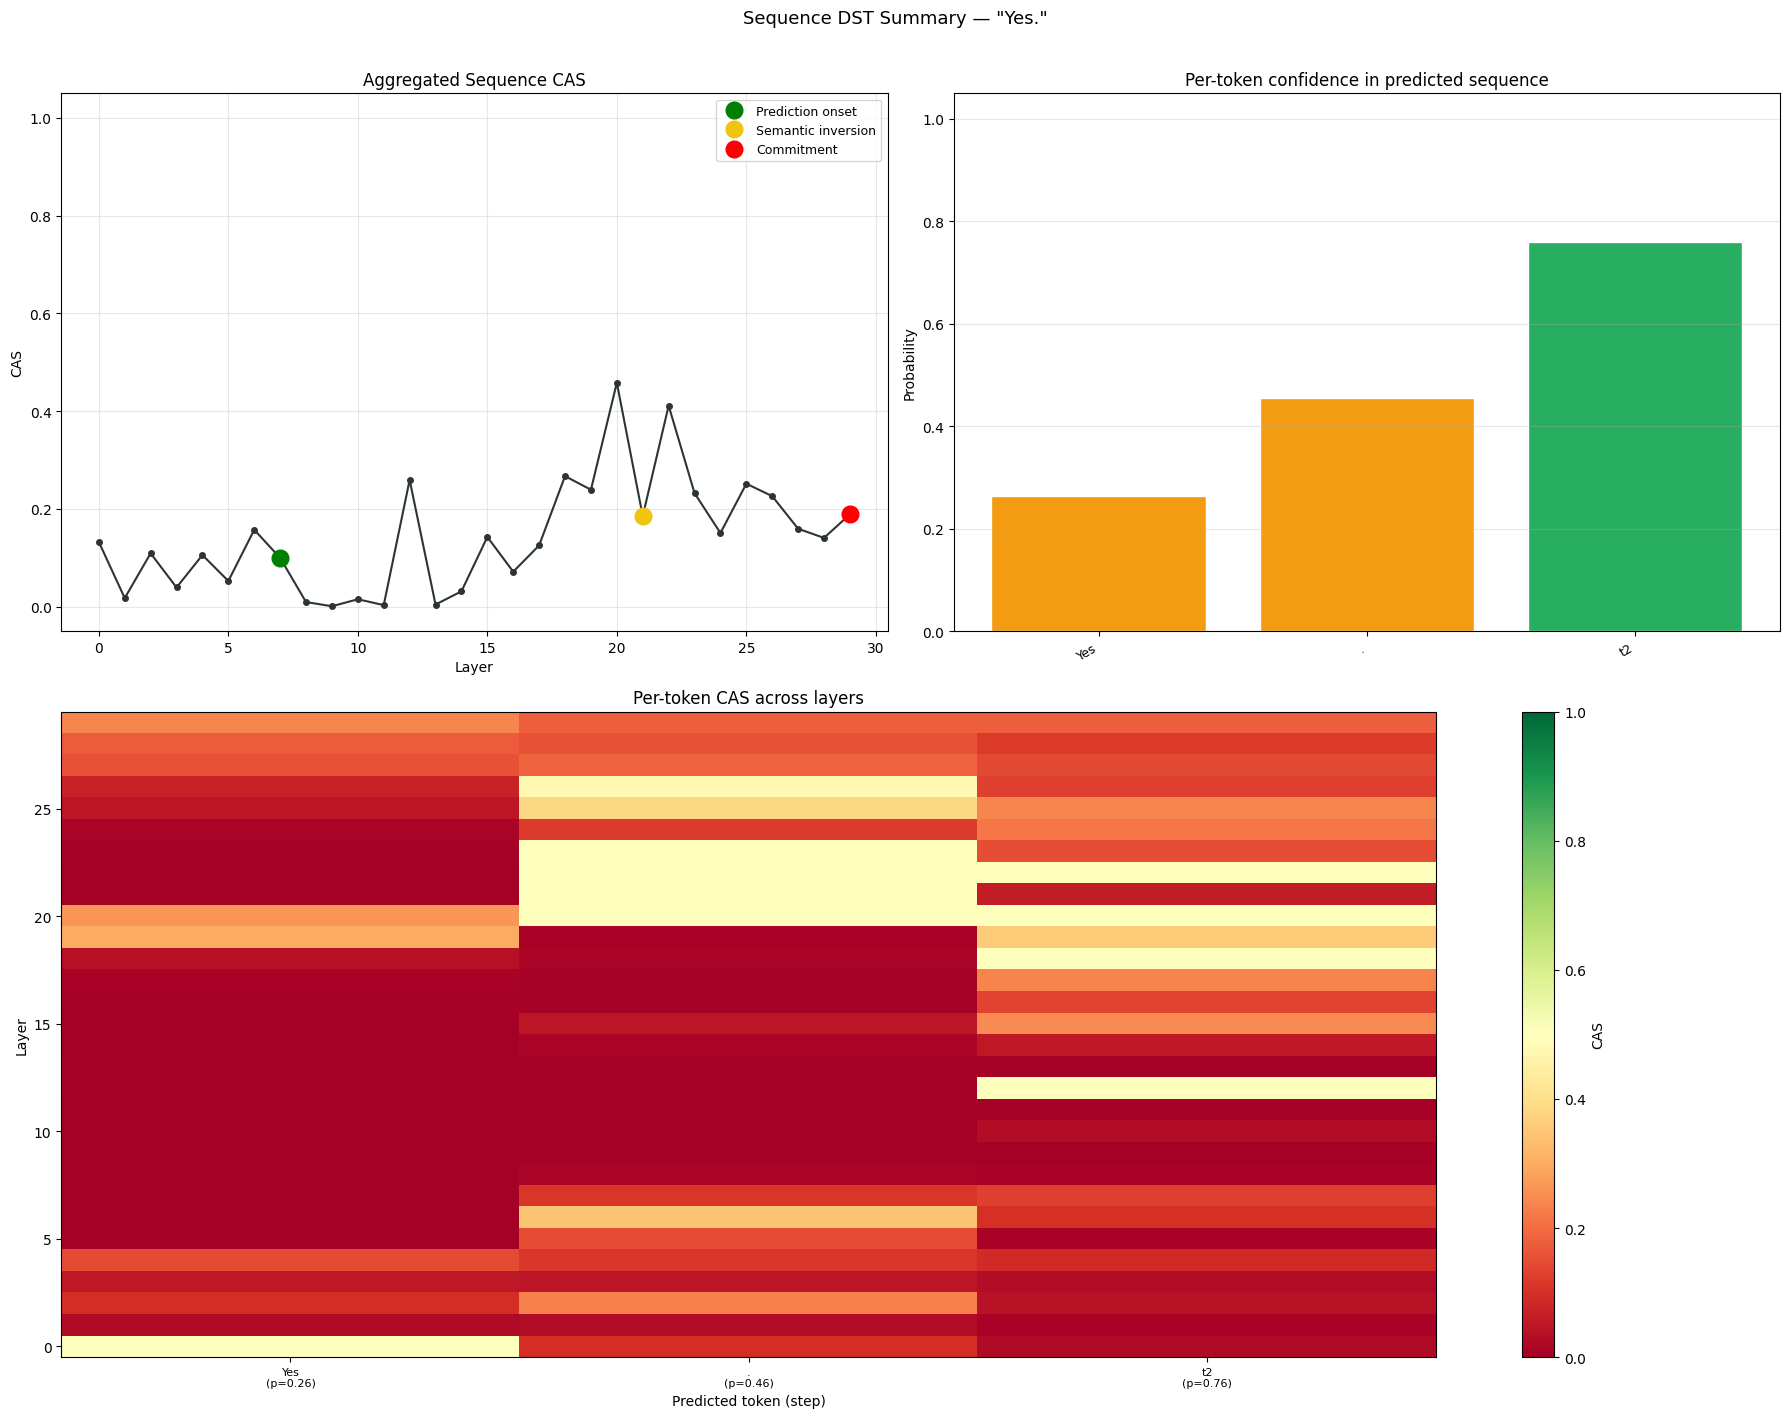

In [71]:
fig = tracer.plot_sequence_summary(
    result_seq,
    context_words=CONTEXT_WORDS,
    noncontext_words=NONCONTEXT_WORDS,
    figsize=(18, 14),
)
plt.show()

## 22. Sequence Layer Markers & Comparison with Single-Token

Compare the operational layer markers (onset, inversion, commitment) from the single-token analysis vs the aggregated sequence analysis.

In [72]:
import pandas as pd

rows = []
# Single-token (first step only)
ct_single = result_prob.cas_trace
cas_s = np.array(ct_single.cas_values) if ct_single.cas_values else np.array([])
rows.append({
    "Analysis": "Single-token (Prob CAS)",
    "Onset": ct_single.onset_layer,
    "Inversion": ct_single.inversion_layer,
    "Commitment": ct_single.commitment_layer,
    "Mean CAS": f"{cas_s.mean():.4f}" if len(cas_s) else "N/A",
    "Final CAS": f"{cas_s[-1]:.4f}" if len(cas_s) else "N/A",
})

# Aggregated sequence
ct_seq = result_seq.sequence_cas_trace
if ct_seq and ct_seq.cas_values:
    cas_q = np.array(ct_seq.cas_values)
    rows.append({
        "Analysis": f"Sequence ({len(result_seq.sequence_steps)}-token, weighted)",
        "Onset": ct_seq.onset_layer,
        "Inversion": ct_seq.inversion_layer,
        "Commitment": ct_seq.commitment_layer,
        "Mean CAS": f"{cas_q.mean():.4f}",
        "Final CAS": f"{cas_q[-1]:.4f}",
    })

# Per-step breakdown
for step in result_seq.sequence_steps:
    ct = step.cas_trace
    if ct.cas_values:
        cv = np.array(ct.cas_values)
        rows.append({
            "Analysis": f"  Step {step.step}: '{step.token_word}' (p={step.token_prob:.3f})",
            "Onset": ct.onset_layer,
            "Inversion": ct.inversion_layer,
            "Commitment": ct.commitment_layer,
            "Mean CAS": f"{cv.mean():.4f}",
            "Final CAS": f"{cv[-1]:.4f}",
        })

df_seq = pd.DataFrame(rows)
display(df_seq)

,Analysis,Onset,Inversion,Commitment,Mean CAS,Final CAS
0,Single-token (Prob CAS),5,1,29,0.0724,0.2384
1,"Sequence (3-token, weighted)",7,21,29,0.1429,0.1890
2,Step 0: 'Yes' (p=0.264),5,1,29,0.0724,0.2384
3,Step 1: '.' (p=0.455),4,20,27,0.1583,0.1787
4,Step 2: '' (p=0.759),2,13,29,0.1582,0.1780


## 23. Single-Token vs Sequence CAS Comparison

Side-by-side comparison of the single-token CAS (first prediction only) against the probability-weighted aggregate across the full predicted sequence.

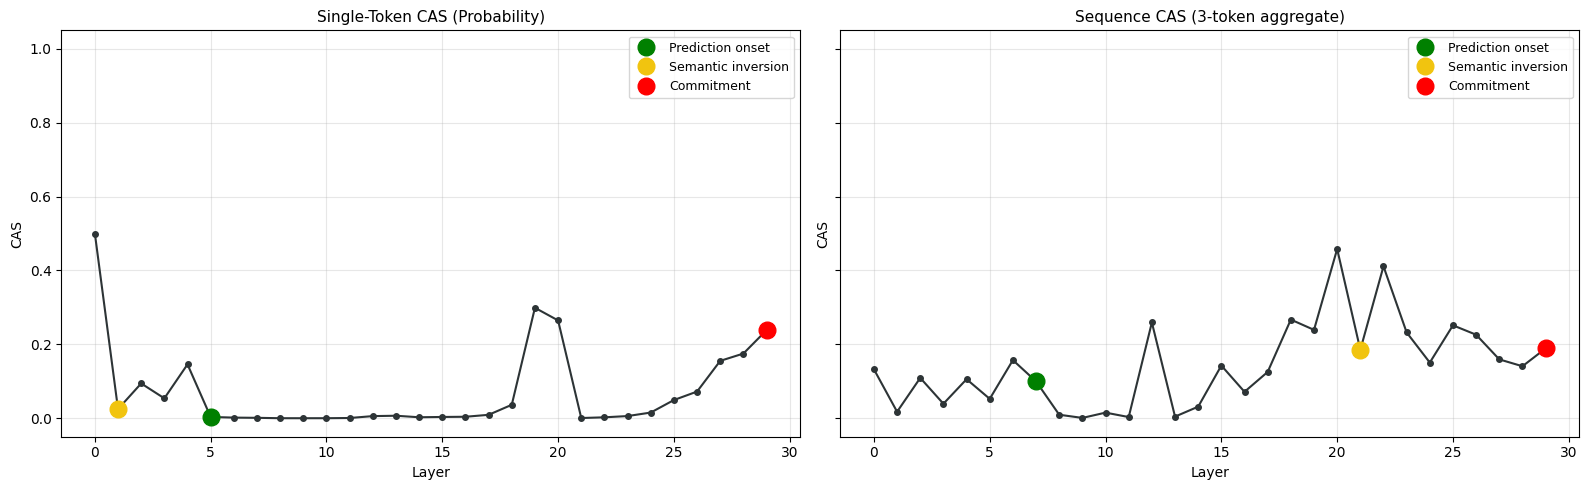

In [73]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

# Left: single-token CAS
if result_prob.cas_trace.cas_values:
    tracer.plot_cas_trace(result_prob.cas_trace, ax=ax1)
    ax1.set_title("Single-Token CAS (Probability)", fontsize=11)

# Right: aggregated sequence CAS
if result_seq.sequence_cas_trace and result_seq.sequence_cas_trace.cas_values:
    tracer.plot_cas_trace(result_seq.sequence_cas_trace, ax=ax2)
    ax2.set_title(
        f"Sequence CAS ({len(result_seq.sequence_steps)}-token aggregate)",
        fontsize=11,
    )

plt.tight_layout()
plt.show()